✅ Data loaded successfully.

Dataset shape: (1025, 14)
Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

🎯 Decision Tree Accuracy: 0.9853658536585366

Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



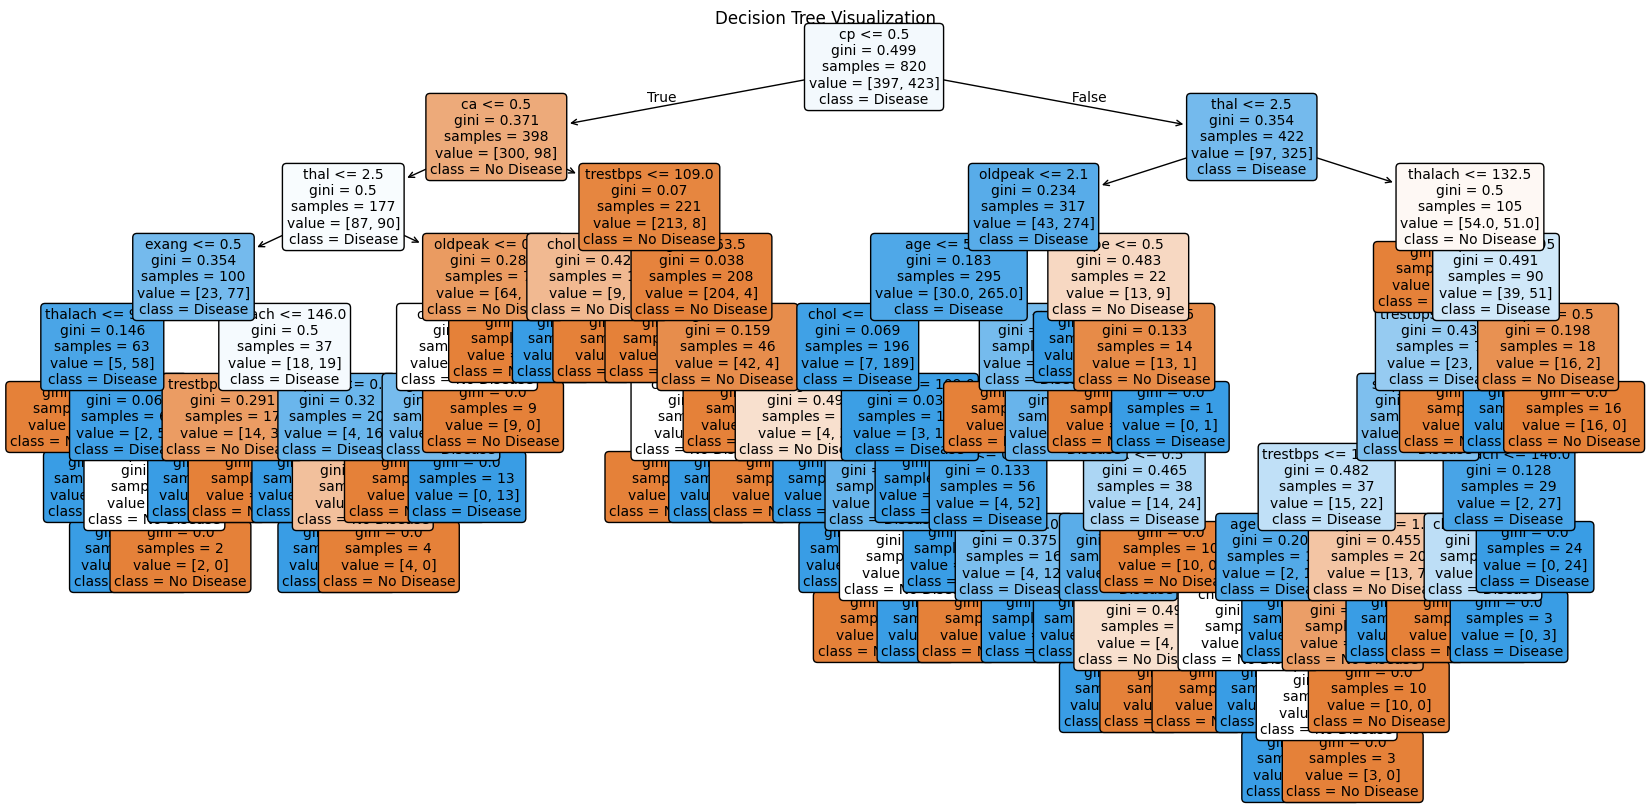

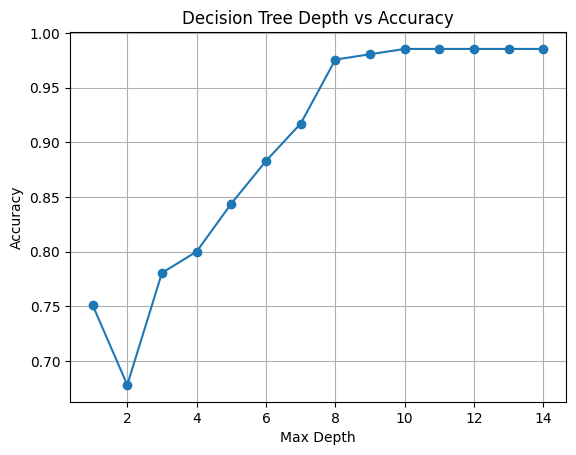


🎯 Random Forest Accuracy: 0.9853658536585366

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



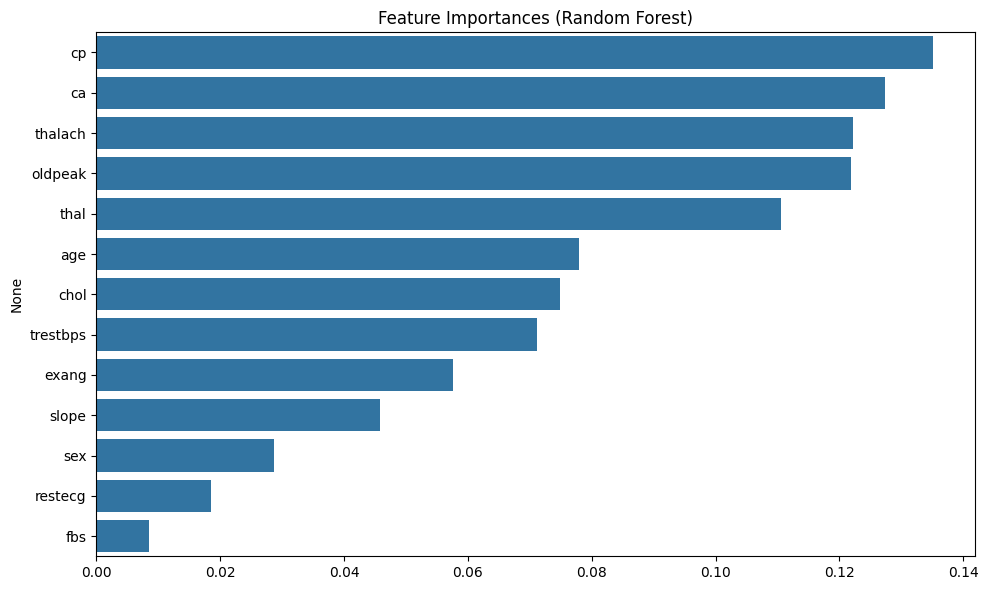


📊 Cross-Validation Scores:
Decision Tree CV Accuracy: 100.00%
Random Forest CV Accuracy: 99.71%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
path = r"C:\Users\TANYA\OneDrive\Desktop\archive\heart.csv"
df = pd.read_csv(path)
print("✅ Data loaded successfully.")

# Basic checks
print("\nDataset shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Train a Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Evaluation
print("\n🎯 Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report (Decision Tree):\n", classification_report(y_test, y_pred_dt))

# 2. Visualize the Decision Tree using matplotlib
plt.figure(figsize=(20, 10))
plot_tree(dt, 
          feature_names=X.columns, 
          class_names=["No Disease", "Disease"], 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization")
plt.savefig("heart_decision_tree.png")
plt.show()

# 3. Analyze Overfitting (Tree Depth Tuning)
depths = range(1, 15)
scores = []
for d in depths:
    temp_model = DecisionTreeClassifier(max_depth=d, random_state=42)
    temp_model.fit(X_train, y_train)
    score = accuracy_score(y_test, temp_model.predict(X_test))
    scores.append(score)

plt.figure()
plt.plot(depths, scores, marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.grid(True)
plt.savefig("depth_vs_accuracy.png")
plt.show()

# 4. Train a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation
print("\n🎯 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))

# 5. Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importances.png")
plt.show()

# 6. Cross-validation
cv_scores_dt = cross_val_score(dt, X, y, cv=5)
cv_scores_rf = cross_val_score(rf, X, y, cv=5)

print("\n📊 Cross-Validation Scores:")
print("Decision Tree CV Accuracy: {:.2f}%".format(np.mean(cv_scores_dt) * 100))
print("Random Forest CV Accuracy: {:.2f}%".format(np.mean(cv_scores_rf) * 100))
